In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/content/drive/MyDrive/lickingpcaoutputs")

Z = np.load(data_dir / "session_1044385384_Z.npy")
X = np.load(data_dir / "session_1044385384_X_proc.npy")
y = np.load(data_dir / "session_1044385384_y.npy")

labels = pd.read_csv(data_dir / "session_1044385384_labels.csv")

print(Z.shape)
print(X.shape)
print(y.shape)

(175189, 10)
(175189, 745)
(175189,)


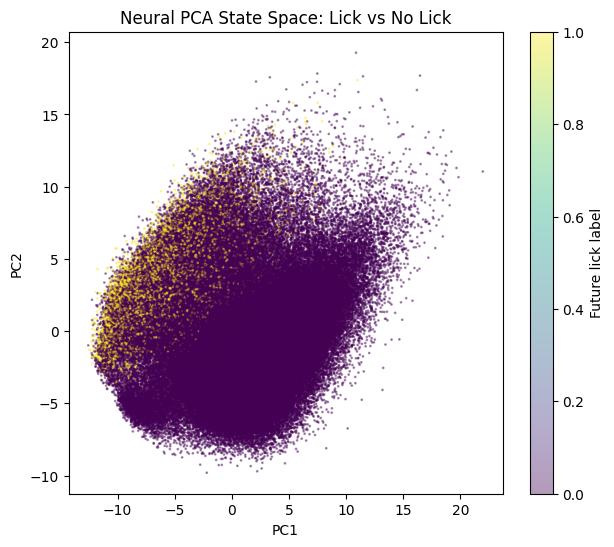

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=y,
    s=1,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural PCA State Space: Lick vs No Lick")
plt.colorbar(label="Future lick label")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/content/drive/MyDrive/lickingpcaoutputs")

Z = np.load(data_dir / "session_1044385384_Z.npy")
y = np.load(data_dir / "session_1044385384_y.npy")
labels = pd.read_csv(data_dir / "session_1044385384_labels.csv")

print("Z shape:", Z.shape)
print("y shape:", y.shape)
print(labels.head())

Z shape: (175189, 10)
y shape: (175189,)
   bin_center_s  future_lick_label
0     26.268883                  0
1     26.318883                  0
2     26.368883                  1
3     26.418883                  1
4     26.468883                  1


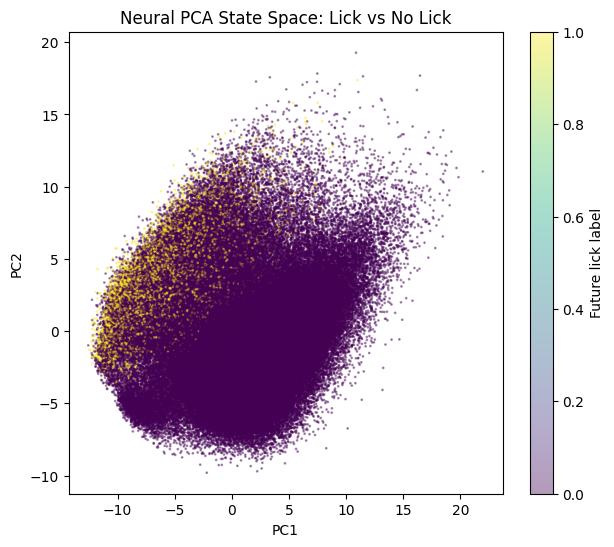

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=y,
    s=1,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural PCA State Space: Lick vs No Lick")
plt.colorbar(label="Future lick label")
plt.show()

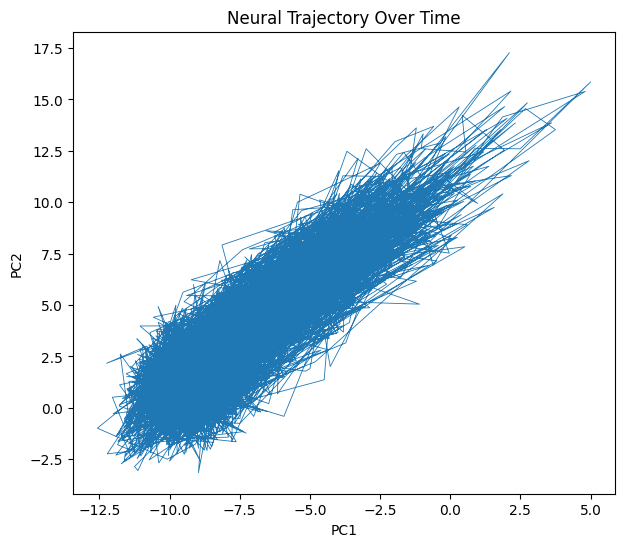

In [ ]:
n = 5000

plt.figure(figsize=(7,6))
plt.plot(Z[:n, 0], Z[:n, 1], linewidth=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural Trajectory Over Time")
plt.show()

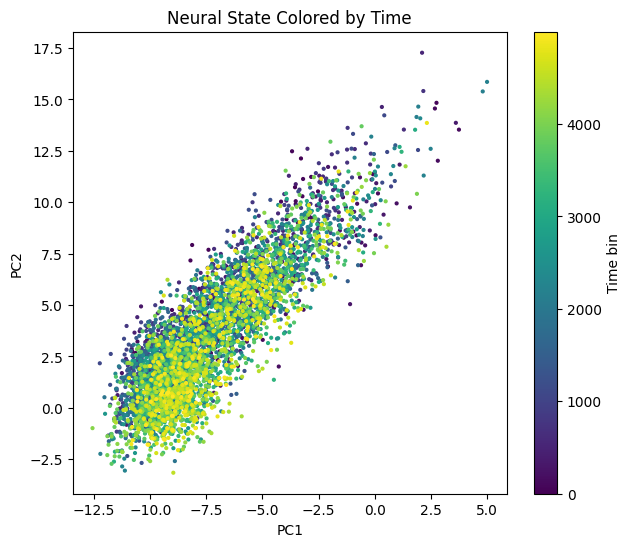

In [ ]:
n = 5000
t = np.arange(n)

plt.figure(figsize=(7,6))

sc = plt.scatter(
    Z[:n, 0],
    Z[:n, 1],
    c=t,
    s=4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural State Colored by Time")
plt.colorbar(sc, label="Time bin")
plt.show()

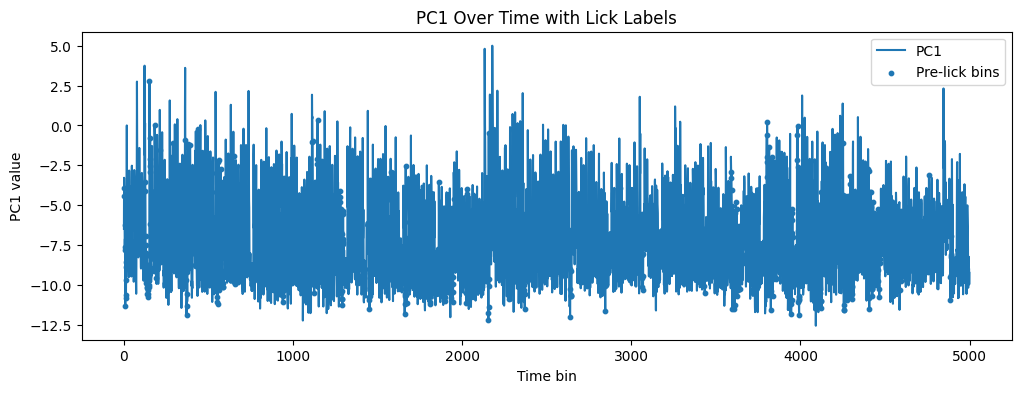

In [ ]:
n = 5000
lick_bins = np.where(y[:n] == 1)[0]

plt.figure(figsize=(12,4))

plt.plot(Z[:n, 0], label="PC1")
plt.scatter(lick_bins, Z[lick_bins, 0], s=10, label="Pre-lick bins")

plt.xlabel("Time bin")
plt.ylabel("PC1 value")
plt.title("PC1 Over Time with Lick Labels")
plt.legend()
plt.show()

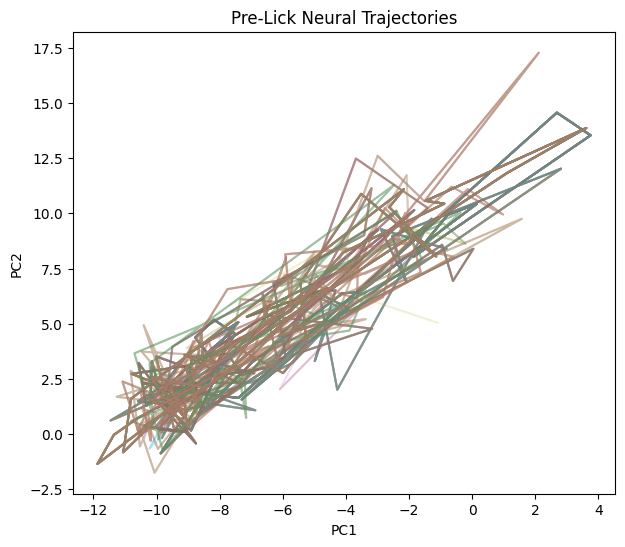

In [ ]:
lick_bins = np.where(y == 1)[0]
window = 40

plt.figure(figsize=(7,6))

for b in lick_bins[:100]:
    if b > window:
        traj = Z[b-window:b, :2]
        plt.plot(traj[:, 0], traj[:, 1], alpha=0.2)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pre-Lick Neural Trajectories")
plt.show()

In [17]:
filtered_units = pd.read_csv(
    data_dir / "session_1044385384_filtered_units.csv"
)

filtered_units_regions = pd.read_csv(
    data_dir / "session_1044385384_filtered_units_with_regions.csv"
)

print(filtered_units.shape)
print(filtered_units_regions.shape)
filtered_units_regions.head()

(745, 26)
(745, 36)


,id,ecephys_channel_id,ecephys_probe_id,ecephys_session_id,amplitude_cutoff,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,left_right_ccf_coordinate,cumulative_drift,d_prime,...,valid_data,amplitude,waveform_duration,waveform_halfwidth,PT_ratio,recovery_slope,repolarization_slope,spread,velocity_above,velocity_below
0,1049374910,1049370173,1044506933,1044385384,0.003587,7935.0,925.0,7577.0,125.59,5.182430,...,True,167.157120,0.796650,0.219765,0.001205,-0.003983,0.608682,70.0,1.579564,0.000000
1,1049374988,1049370201,1044506933,1044385384,0.021714,7925.0,648.0,7606.0,81.35,5.067903,...,True,137.207558,2.101508,0.535678,0.028738,NaN,0.209681,80.0,-0.018561,0.343384
2,1049373561,1049369923,1044506933,1044385384,0.001217,8132.0,3730.0,7396.0,122.49,6.465114,...,True,244.048350,0.384590,0.233501,0.536964,-0.192427,0.790600,70.0,0.549414,0.343384
3,1049373556,1049369923,1044506933,1044385384,0.054373,8132.0,3730.0,7396.0,136.20,4.153785,...,True,155.097930,0.398325,0.260972,0.548738,-0.116262,0.531634,70.0,0.755444,0.068677
4,1049373165,1049369881,1044506933,1044385384,0.098678,8166.0,4138.0,7338.0,0.00,3.422304,...,True,56.878764,1.194975,0.508208,0.036635,-0.017114,0.205490,80.0,-0.016352,NaN


In [18]:
region_counts = filtered_units_regions["structure_acronym"].value_counts()

region_counts

,count
structure_acronym,
CA1,151
VISpm,91
VISl,82
POL,63
DG,53
VISrl,47
LP,37
MRN,30
VISal,28


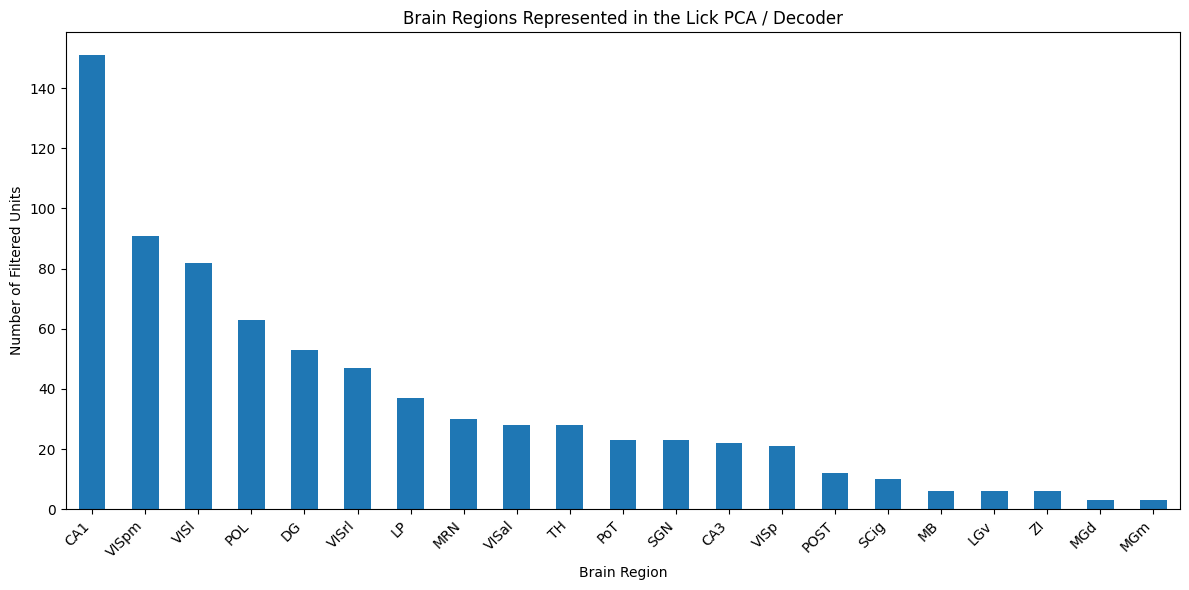

In [19]:
plt.figure(figsize=(12, 6))

region_counts.plot(kind="bar")

plt.xlabel("Brain Region")
plt.ylabel("Number of Filtered Units")
plt.title("Brain Regions Represented in the Lick PCA / Decoder")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

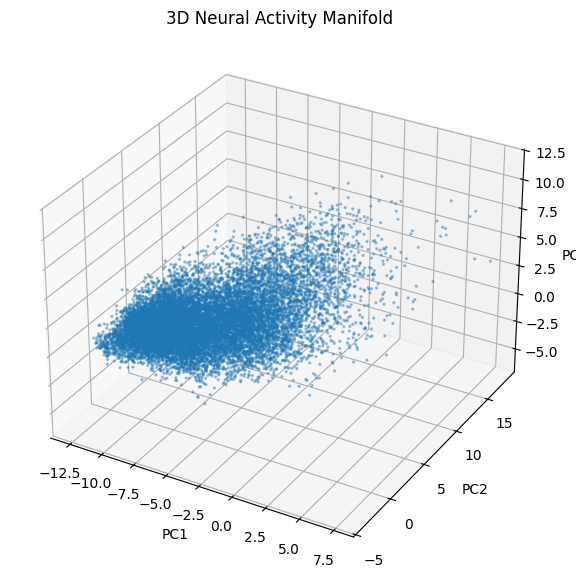

In [21]:
from mpl_toolkits.mplot3d import Axes3D

n = 15000

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z[:n, 0],
    Z[:n, 1],
    Z[:n, 2],
    s=2,
    alpha=0.35
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Neural Activity Manifold")

plt.show()